# Проект модуля: Retrieval-система по статьям arXiv

**Цель:** построить и сравнить несколько методов retrieval по корпусу arXiv и добиться **MRR@5 > 0.91**.

В работе последовательно рассматриваются:
1. анализ и подготовка данных;
2. лексический baseline TF-IDF;
3. dense retrieval с bi-encoder;
4. точный поиск FAISS `IndexFlatIP`;
5. приближённые индексы `IndexIVFFlat` и `IndexHNSWFlat`;
6. сравнение качества, скорости и компромисса quality/latency;
7. дальнейшее улучшение качества retrieval.

> Результаты предыдущей итерации используются как контрольные значения, но метрики скорости ниже пересчитываются корректно: кодирование запросов отделено от непосредственно поиска по индексу.

## 1. Импорты и воспроизводимость

In [1]:
import json
import time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer

import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel

from sentence_transformers import CrossEncoder

import faiss

from tqdm.auto import tqdm

C:\Users\pdiul\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Загрузка данных

Файл метаданных в данном проекте представляет собой обычный JSON-массив, поэтому загружается через `json.load`, а не построчно как JSONL.

In [2]:
with open("arxiv-metadata-s.json", "r", encoding="utf-8") as f:
    metadata = json.load(f)

metadata_df = pd.DataFrame(metadata)
test_df = pd.read_csv("test_sample.csv")

print("Metadata:", metadata_df.shape)
print("Test:", test_df.shape)

display(metadata_df.head(3))
display(test_df.head(3))

Metadata: (98213, 14)
Test: (1000, 3)


,id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,versions,update_date,authors_parsed
0,0704.0038,Maxim A. Yurkin,"Maxim A. Yurkin, Alfons G. Hoekstra",The discrete dipole approximation: an overview...,"36 pages, 1 figure; added several corrections ...","J.Quant.Spectrosc.Radiat.Transf. 106, 558-589 ...",10.1016/j.jqsrt.2007.01.034 10.1016/j.jqsrt.20...,NaN,physics.optics physics.comp-ph,http://creativecommons.org/licenses/by-nc-nd/4.0/,We present a review of the discrete dipole a...,"[{'version': 'v1', 'created': 'Sat, 31 Mar 200...",2022-03-30,"[[Yurkin, Maxim A., ], [Hoekstra, Alfons G., ]]"
1,0704.0057,Philipp Werner,Philipp Werner and Andrew J. Millis,High-spin to low-spin and orbital polarization...,Published version,"Phys. Rev. Lett. 99, 126405 (2007)",10.1103/PhysRevLett.99.126405,NaN,cond-mat.str-el,NaN,We study the interplay of crystal field spli...,"[{'version': 'v1', 'created': 'Sun, 1 Apr 2007...",2009-11-13,"[[Werner, Philipp, ], [Millis, Andrew J., ]]"
2,0704.0060,Carlos Bertulani,"C.A. Bertulani, G. Cardella, M. De Napoli, G. ...",Coulomb excitation of unstable nuclei at inter...,"12 pages, 2 figures, accepted for publication ...","Phys.Lett.B650:233-238,2007",10.1016/j.physletb.2007.05.029,NaN,nucl-th,NaN,We investigate the Coulomb excitation of low...,"[{'version': 'v1', 'created': 'Sat, 31 Mar 200...",2008-11-26,"[[Bertulani, C. A., ], [Cardella, G., ], [De N..."


,id,abstract,query
0,2412.16732,A new platinate was recently discovered when...,What unique composition and decomposition beha...
1,nucl-th/9602019,The production cross sections of various fra...,How does the inclusion of statistical decay af...
2,2501.05500,This survey provides a comprehensive examina...,What are the core components of modern zero-kn...


## 3. Проверка качества данных

In [3]:
print("Документов:", len(metadata_df))
print("Уникальных metadata ID:", metadata_df["id"].nunique())
print("Дубликатов metadata ID:", metadata_df["id"].duplicated().sum())
print()
print("Тестовых запросов:", len(test_df))
print("Уникальных test ID:", test_df["id"].nunique())
print("Дубликатов test ID:", test_df["id"].duplicated().sum())
print("Пустых query:", test_df["query"].isna().sum())

missing_ids = set(test_df["id"].astype(str)) - set(metadata_df["id"].astype(str))
print("Test ID, отсутствующих в metadata:", len(missing_ids))

metadata_df.info()

Документов: 98213
Уникальных metadata ID: 98213
Дубликатов metadata ID: 0

Тестовых запросов: 1000
Уникальных test ID: 1000
Дубликатов test ID: 0
Пустых query: 0
Test ID, отсутствующих в metadata: 0
<class 'pandas.DataFrame'>
RangeIndex: 98213 entries, 0 to 98212
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              98213 non-null  str   
 1   submitter       97650 non-null  str   
 2   authors         98213 non-null  str   
 3   title           98213 non-null  str   
 4   comments        72275 non-null  str   
 5   journal-ref     31672 non-null  str   
 6   doi             43744 non-null  str   
 7   report-no       6558 non-null   str   
 8   categories      98213 non-null  str   
 9   license         82351 non-null  str   
 10  abstract        98213 non-null  str   
 11  versions        98213 non-null  object
 12  update_date     98213 non-null  str   
 13  authors_parsed  98213 non-null  object

## 4. Подготовка корпуса

Для retrieval используется объединение `title + abstract`. Категории сохраняются для EDA, но в поисковый текст на этом этапе не добавляются.

In [4]:
corpus_df = metadata_df[["id", "title", "abstract", "categories"]].copy()

for col in ["title", "abstract", "categories"]:
    corpus_df[col] = corpus_df[col].fillna("")

corpus_df["id"] = corpus_df["id"].astype(str)
test_df["id"] = test_df["id"].astype(str)

corpus_df["text"] = corpus_df["title"] + ". " + corpus_df["abstract"]

print("Размер корпуса:", len(corpus_df))
display(corpus_df.head(3))

Размер корпуса: 98213


,id,title,abstract,categories,text
0,0704.0038,The discrete dipole approximation: an overview...,We present a review of the discrete dipole a...,physics.optics physics.comp-ph,The discrete dipole approximation: an overview...
1,0704.0057,High-spin to low-spin and orbital polarization...,We study the interplay of crystal field spli...,cond-mat.str-el,High-spin to low-spin and orbital polarization...
2,0704.0060,Coulomb excitation of unstable nuclei at inter...,We investigate the Coulomb excitation of low...,nucl-th,Coulomb excitation of unstable nuclei at inter...


## 5. EDA

In [5]:
eda = pd.DataFrame({
    "metric": ["query_len", "test_abstract_len", "corpus_abstract_len"],
    "mean": [
        test_df["query"].str.len().mean(),
        test_df["abstract"].str.len().mean(),
        corpus_df["abstract"].str.len().mean(),
    ],
    "median": [
        test_df["query"].str.len().median(),
        test_df["abstract"].str.len().median(),
        corpus_df["abstract"].str.len().median(),
    ],
    "max": [
        test_df["query"].str.len().max(),
        test_df["abstract"].str.len().max(),
        corpus_df["abstract"].str.len().max(),
    ]
})

display(eda)

category_counts = Counter()
for categories in corpus_df["categories"]:
    category_counts.update(categories.split())

top_categories = pd.DataFrame(category_counts.most_common(15), columns=["category", "count"])
display(top_categories)

,metric,mean,median,max
0,query_len,126.886000,123.5,238
1,test_abstract_len,995.528000,949.5,3506
2,corpus_abstract_len,981.934174,958.0,3874


,category,count
0,cs.LG,8152
1,hep-ph,6692
2,hep-th,6111
3,quant-ph,5783
4,cs.CV,5668
5,cs.AI,4842
6,gr-qc,4096
7,astro-ph,3754
8,cond-mat.mtrl-sci,3634
9,cond-mat.mes-hall,3380


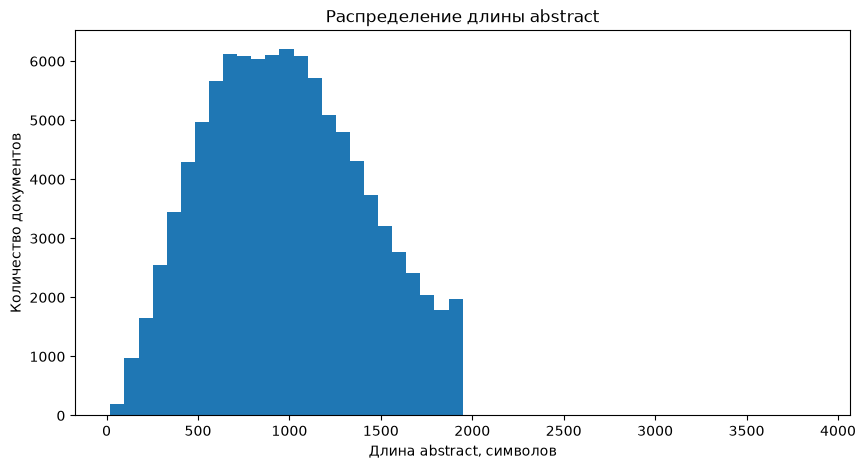

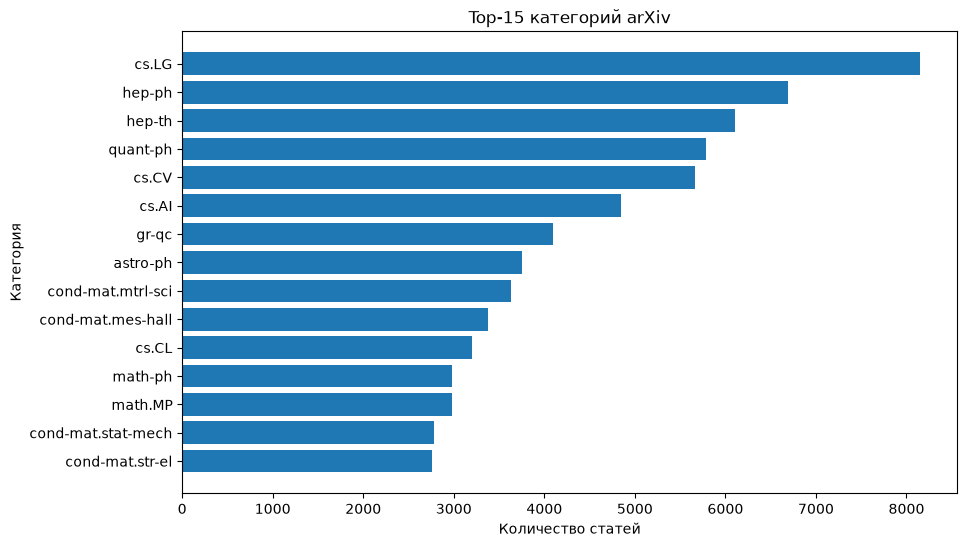

In [6]:
plt.figure(figsize=(10, 5))
plt.hist(corpus_df["abstract"].str.len(), bins=50)
plt.xlabel("Длина abstract, символов")
plt.ylabel("Количество документов")
plt.title("Распределение длины abstract")
plt.show()

plt.figure(figsize=(10, 6))
plt.barh(top_categories["category"][::-1], top_categories["count"][::-1])
plt.xlabel("Количество статей")
plt.ylabel("Категория")
plt.title("Top-15 категорий arXiv")
plt.show()

## 6. Метрики

Основная метрика проекта — **MRR@5**. Дополнительно считаем **Recall@5**: долю запросов, для которых релевантный документ вообще попал в первые 5 результатов.

In [7]:
def reciprocal_rank(retrieved_ids, relevant_id, k=5):
    relevant_id = str(relevant_id)
    for rank, doc_id in enumerate(retrieved_ids[:k], start=1):
        if str(doc_id) == relevant_id:
            return 1.0 / rank
    return 0.0


def metrics_from_indices(indices, test_df, corpus_ids, k=5):
    reciprocal_ranks = []
    hits = []

    for i, (_, row) in enumerate(test_df.iterrows()):
        retrieved_ids = corpus_ids[indices[i, :k]]
        relevant_id = str(row["id"])
        reciprocal_ranks.append(reciprocal_rank(retrieved_ids, relevant_id, k))
        hits.append(relevant_id in {str(x) for x in retrieved_ids})

    return {
        "mrr@5": float(np.mean(reciprocal_ranks)),
        "recall@5": float(np.mean(hits)),
    }

## 7. Baseline: TF-IDF

TF-IDF служит лексическим baseline. В предыдущем запуске получено **MRR@5 = 0.8209**. Ниже результат пересчитывается воспроизводимо.

In [8]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    max_features=500_000,
)

start = time.perf_counter()
document_matrix = vectorizer.fit_transform(corpus_df["text"])
tfidf_build_time = time.perf_counter() - start

print("TF-IDF matrix:", document_matrix.shape)
print(f"Build time: {tfidf_build_time:.2f} sec")

TF-IDF matrix: (98213, 500000)
Build time: 24.11 sec


In [9]:
def evaluate_tfidf(test_df, k=5):
    reciprocal_ranks = []
    hits = []
    corpus_ids = corpus_df["id"].to_numpy()

    start = time.perf_counter()
    for _, row in test_df.iterrows():
        query_vector = vectorizer.transform([row["query"]])
        scores = (document_matrix @ query_vector.T).toarray().ravel()
        top_indices = np.argpartition(-scores, k - 1)[:k]
        top_indices = top_indices[np.argsort(-scores[top_indices])]
        retrieved_ids = corpus_ids[top_indices]
        relevant_id = str(row["id"])
        reciprocal_ranks.append(reciprocal_rank(retrieved_ids, relevant_id, k))
        hits.append(relevant_id in {str(x) for x in retrieved_ids})
    elapsed = time.perf_counter() - start

    return {
        "mrr@5": float(np.mean(reciprocal_ranks)),
        "recall@5": float(np.mean(hits)),
        "total_time_sec": elapsed,
        "latency_ms": elapsed / len(test_df) * 1000,
    }

tfidf_result = evaluate_tfidf(test_df, k=5)
tfidf_result

{'mrr@5': 0.8209166666666666,
 'recall@5': 0.898,
 'total_time_sec': 46.028579199977685,
 'latency_ms': 46.028579199977685}

## 8. Dense retrieval: bi-encoder MiniLM

В первой dense-итерации используется `sentence-transformers/all-MiniLM-L6-v2`. Для документов и запросов применяется одинаковое mean pooling и L2-нормализация. После нормализации inner product эквивалентен cosine similarity.

Предыдущий контрольный результат с `IndexFlatIP`: **MRR@5 ≈ 0.8472**.

In [10]:
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(device)
model.eval()

Device: cuda


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12104.94it/s]


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 384, padding_idx=0)
    (position_embeddings): Embedding(512, 384)
    (token_type_embeddings): Embedding(2, 384)
    (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-5): 6 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=384, out_features=384, bias=True)
            (key): Linear(in_features=384, out_features=384, bias=True)
            (value): Linear(in_features=384, out_features=384, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=384, out_features=384, bias=True)
            (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
    

In [11]:
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output.last_hidden_state
    mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * mask, dim=1) / torch.clamp(mask.sum(dim=1), min=1e-9)


@torch.no_grad()
def encode_texts(texts, batch_size=64, max_length=512):
    all_embeddings = []

    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        ).to(device)

        outputs = model(**inputs)
        embeddings = mean_pooling(outputs, inputs["attention_mask"])
        embeddings = F.normalize(embeddings, p=2, dim=1)
        all_embeddings.append(embeddings.cpu().numpy().astype("float32"))

    return np.vstack(all_embeddings)

### 8.1 Кодирование документов и запросов

Ключевое исправление относительно предыдущей версии: **1000 test queries кодируются один раз**. Поэтому далее latency FAISS измеряется отдельно от neural encoding latency.

In [12]:
start = time.perf_counter()
document_embeddings = encode_texts(corpus_df["text"].tolist(), batch_size=64, max_length=512)
document_encoding_time = time.perf_counter() - start

start = time.perf_counter()
test_query_embeddings = encode_texts(test_df["query"].tolist(), batch_size=64, max_length=512)
query_encoding_time = time.perf_counter() - start

print("Document embeddings:", document_embeddings.shape)
print("Query embeddings:", test_query_embeddings.shape)
print(f"Document encoding: {document_encoding_time:.2f} sec")
print(f"Query encoding: {query_encoding_time:.2f} sec")
print(f"Query encoding latency: {query_encoding_time / len(test_df) * 1000:.3f} ms/query")
print(f"Embeddings memory: {document_embeddings.nbytes / 1024**2:.2f} MB")

Document embeddings: (98213, 384)
Query embeddings: (1000, 384)
Document encoding: 113.68 sec
Query encoding: 0.14 sec
Query encoding latency: 0.144 ms/query
Embeddings memory: 143.87 MB


## 9. FAISS: точный поиск IndexFlatIP

In [13]:
dimension = document_embeddings.shape[1]
corpus_ids = corpus_df["id"].to_numpy()

index_flat = faiss.IndexFlatIP(dimension)
index_flat.add(document_embeddings)

print("Vectors:", index_flat.ntotal)

Vectors: 98213


In [14]:
def evaluate_index(index, query_embeddings, test_df, k=5):
    start = time.perf_counter()
    scores, indices = index.search(query_embeddings, k)
    search_time = time.perf_counter() - start

    result = metrics_from_indices(indices, test_df, corpus_ids, k=k)
    result.update({
        "search_time_sec": search_time,
        "search_latency_ms": search_time / len(test_df) * 1000,
    })
    return result

flat_result = evaluate_index(index_flat, test_query_embeddings, test_df, k=5)
flat_result

{'mrr@5': 0.8472166666666667,
 'recall@5': 0.914,
 'search_time_sec': 0.287852399982512,
 'search_latency_ms': 0.287852399982512}

### 9.1 Пример семантического поиска

In [15]:
def dense_search(query, index=index_flat, top_k=5):
    query_embedding = encode_texts([query], batch_size=1, max_length=512)
    scores, indices = index.search(query_embedding, top_k)
    result = corpus_df.iloc[indices[0]].copy()
    result["score"] = scores[0]
    return result[["id", "title", "abstract", "score"]].reset_index(drop=True)

query = "How does machine learning improve image classification?"
display(dense_search(query, top_k=5)[["id", "title", "score"]])

,id,title,score
0,2412.19208,Developing Explainable Machine Learning Model ...,0.541969
1,2006.14699,Learning Data Augmentation with Online Bilevel...,0.537808
2,2409.17685,Feature-to-Image Data Augmentation: Improving ...,0.531214
3,1903.00405,Quantifying contribution and propagation of er...,0.529950
4,1703.05451,Refining Image Categorization by Exploiting We...,0.526905


## 10. Approximate retrieval: IndexIVFFlat

Проверяем компромисс между скоростью и качеством при разных `nprobe`. Контроль предыдущей итерации: качество росло от **0.7293** (`nprobe=4`) до **0.8472** (`nprobe=256`).

In [16]:
nlist = 256
quantizer = faiss.IndexFlatIP(dimension)
index_ivf = faiss.IndexIVFFlat(quantizer, dimension, nlist, faiss.METRIC_INNER_PRODUCT)

start = time.perf_counter()
index_ivf.train(document_embeddings)
index_ivf.add(document_embeddings)
ivf_build_time = time.perf_counter() - start

print("Vectors:", index_ivf.ntotal)
print(f"Build time: {ivf_build_time:.2f} sec")
print("nlist:", nlist)

Vectors: 98213
Build time: 0.75 sec
nlist: 256


In [17]:
ivf_results = []

for nprobe in [4, 8, 16, 32, 64, 128, 256]:
    index_ivf.nprobe = nprobe
    result = evaluate_index(index_ivf, test_query_embeddings, test_df, k=5)
    ivf_results.append({"nprobe": nprobe, **result})

ivf_results_df = pd.DataFrame(ivf_results)
display(ivf_results_df)

,nprobe,mrr@5,recall@5,search_time_sec,search_latency_ms
0,4,0.729283,0.780,0.047328,0.047328
1,8,0.784300,0.841,0.087402,0.087402
2,16,0.819683,0.882,0.167219,0.167219
3,32,0.837317,0.902,0.278115,0.278115
4,64,0.844183,0.910,0.481597,0.481597
5,128,0.846217,0.913,0.913841,0.913841
6,256,0.847217,0.914,1.777864,1.777864


## 11. Approximate retrieval: HNSW

Параметры первой серии экспериментов: `M=32`, `efConstruction=200`. Контроль предыдущей итерации: **MRR@5 0.7658 → 0.8463** при росте `efSearch` от 8 до 256.

In [18]:
M = 32
efConstruction = 200

index_hnsw = faiss.IndexHNSWFlat(dimension, M, faiss.METRIC_INNER_PRODUCT)
index_hnsw.hnsw.efConstruction = efConstruction

start = time.perf_counter()
index_hnsw.add(document_embeddings)
hnsw_build_time = time.perf_counter() - start

print("Vectors:", index_hnsw.ntotal)
print(f"Build time: {hnsw_build_time:.2f} sec")
print("M:", M)
print("efConstruction:", efConstruction)

Vectors: 98213
Build time: 10.16 sec
M: 32
efConstruction: 200


In [19]:
hnsw_results = []

for ef_search in [8, 16, 32, 64, 128, 256]:
    index_hnsw.hnsw.efSearch = ef_search
    result = evaluate_index(index_hnsw, test_query_embeddings, test_df, k=5)
    hnsw_results.append({"efSearch": ef_search, **result})

hnsw_results_df = pd.DataFrame(hnsw_results)
display(hnsw_results_df)

,efSearch,mrr@5,recall@5,search_time_sec,search_latency_ms
0,8,0.765817,0.819,0.013123,0.013123
1,16,0.806317,0.867,0.012633,0.012633
2,32,0.833067,0.897,0.031147,0.031147
3,64,0.840850,0.906,0.038182,0.038182
4,128,0.844800,0.910,0.061642,0.061642
5,256,0.846300,0.912,0.124670,0.124670


## 12. Сравнение индексов

In [20]:
best_ivf = ivf_results_df.loc[ivf_results_df["mrr@5"].idxmax()]
best_hnsw = hnsw_results_df.loc[hnsw_results_df["mrr@5"].idxmax()]

comparison_df = pd.DataFrame([
    {
        "method": "TF-IDF",
        "mrr@5": tfidf_result["mrr@5"],
        "recall@5": tfidf_result["recall@5"],
        "latency_ms": tfidf_result["latency_ms"],
    },
    {
        "method": "MiniLM + FlatIP",
        "mrr@5": flat_result["mrr@5"],
        "recall@5": flat_result["recall@5"],
        "latency_ms": flat_result["search_latency_ms"],
    },
    {
        "method": f"MiniLM + IVFFlat (nprobe={int(best_ivf['nprobe'])})",
        "mrr@5": best_ivf["mrr@5"],
        "recall@5": best_ivf["recall@5"],
        "latency_ms": best_ivf["search_latency_ms"],
    },
    {
        "method": f"MiniLM + HNSW (efSearch={int(best_hnsw['efSearch'])})",
        "mrr@5": best_hnsw["mrr@5"],
        "recall@5": best_hnsw["recall@5"],
        "latency_ms": best_hnsw["search_latency_ms"],
    },
])

display(comparison_df)

,method,mrr@5,recall@5,latency_ms
0,TF-IDF,0.820917,0.898,46.028579
1,MiniLM + FlatIP,0.847217,0.914,0.287852
2,MiniLM + IVFFlat (nprobe=256),0.847217,0.914,1.777864
3,MiniLM + HNSW (efSearch=256),0.846300,0.912,0.124670


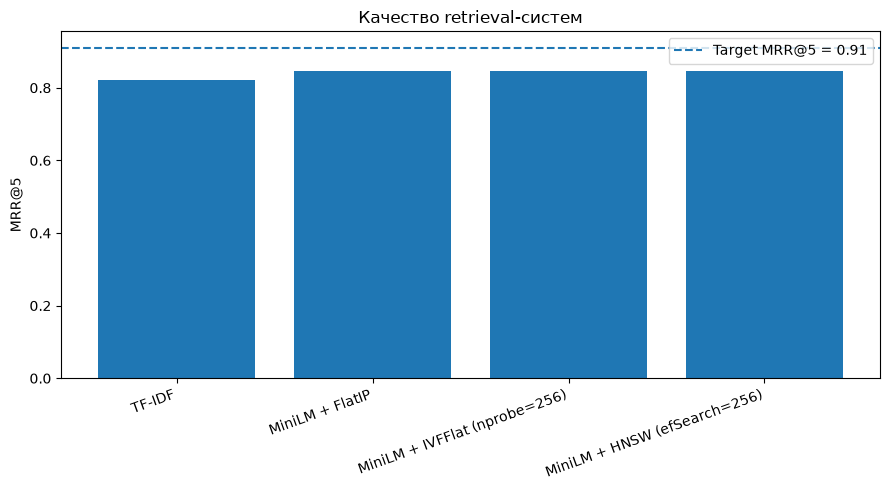

In [21]:
plt.figure(figsize=(9, 5))
plt.bar(comparison_df["method"], comparison_df["mrr@5"])
plt.axhline(0.91, linestyle="--", label="Target MRR@5 = 0.91")
plt.ylabel("MRR@5")
plt.title("Качество retrieval-систем")
plt.xticks(rotation=20, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Промежуточные выводы

Результаты предыдущей итерации показали:

- TF-IDF: **MRR@5 = 0.8209**;
- MiniLM + exact `IndexFlatIP`: **MRR@5 ≈ 0.8472**;
- `IndexIVFFlat` при увеличении `nprobe` приближается к качеству exact search;
- HNSW при увеличении `efSearch` также приближается к FlatIP и позволяет получить хороший speed/quality trade-off;
- изменение структуры FAISS-индекса не способно преодолеть потолок качества текущего bi-encoder: exact FlatIP уже показывает около 0.8472, что ниже целевого **0.91**.

Поэтому дальнейшая работа должна улучшать **представление и ранжирование документов**, а не только параметры ANN-индекса.

### Следующие эксперименты

1. Сравнить MiniLM с более сильным англоязычным retrieval-oriented bi-encoder при неизменном `IndexFlatIP`.
2. Для лучшего bi-encoder измерить Recall@K на большем K (например, 20/50/100).
3. Если релевантный документ часто присутствует в candidate set, применить cross-encoder reranking к top-N кандидатам.
4. После достижения требуемого качества снова выбрать оптимальный approximate index по latency/quality.

> Целевой показатель проекта: **MRR@5 > 0.91**.

## 14. Контрольные результаты предыдущей итерации

Эта таблица сохранена для проверки воспроизводимости после рефакторинга. Старые значения времени включали повторное neural encoding каждого запроса и поэтому **не должны использоваться как чистая latency FAISS**.

In [22]:
previous_results = pd.DataFrame([
    {"experiment": "TF-IDF", "parameter": "-", "mrr@5": 0.8209, "old_time_sec": 48.95},
    {"experiment": "MiniLM + FlatIP", "parameter": "-", "mrr@5": 0.8472, "old_time_sec": 13.06},
    {"experiment": "IVFFlat", "parameter": "nprobe=4", "mrr@5": 0.729283, "old_time_sec": 5.433801},
    {"experiment": "IVFFlat", "parameter": "nprobe=8", "mrr@5": 0.784300, "old_time_sec": 5.616402},
    {"experiment": "IVFFlat", "parameter": "nprobe=16", "mrr@5": 0.819683, "old_time_sec": 5.741559},
    {"experiment": "IVFFlat", "parameter": "nprobe=32", "mrr@5": 0.837317, "old_time_sec": 6.310586},
    {"experiment": "IVFFlat", "parameter": "nprobe=64", "mrr@5": 0.844183, "old_time_sec": 7.572421},
    {"experiment": "IVFFlat", "parameter": "nprobe=128", "mrr@5": 0.846217, "old_time_sec": 10.166765},
    {"experiment": "IVFFlat", "parameter": "nprobe=256", "mrr@5": 0.847217, "old_time_sec": 14.759727},
    {"experiment": "HNSW", "parameter": "efSearch=8", "mrr@5": 0.765817, "old_time_sec": 4.832464},
    {"experiment": "HNSW", "parameter": "efSearch=16", "mrr@5": 0.806317, "old_time_sec": 4.737871},
    {"experiment": "HNSW", "parameter": "efSearch=32", "mrr@5": 0.833067, "old_time_sec": 4.923973},
    {"experiment": "HNSW", "parameter": "efSearch=64", "mrr@5": 0.840850, "old_time_sec": 4.872462},
    {"experiment": "HNSW", "parameter": "efSearch=128", "mrr@5": 0.844800, "old_time_sec": 5.718595},
    {"experiment": "HNSW", "parameter": "efSearch=256", "mrr@5": 0.846300, "old_time_sec": 6.018854},
])

display(previous_results)

,experiment,parameter,mrr@5,old_time_sec
0,TF-IDF,-,0.820900,48.950000
1,MiniLM + FlatIP,-,0.847200,13.060000
2,IVFFlat,nprobe=4,0.729283,5.433801
3,IVFFlat,nprobe=8,0.784300,5.616402
4,IVFFlat,nprobe=16,0.819683,5.741559
5,IVFFlat,nprobe=32,0.837317,6.310586
6,IVFFlat,nprobe=64,0.844183,7.572421
7,IVFFlat,nprobe=128,0.846217,10.166765
8,IVFFlat,nprobe=256,0.847217,14.759727
9,HNSW,efSearch=8,0.765817,4.832464


## 15. Анализ Recall@K

Перед добавлением reranker проверим, насколько часто правильный документ
попадает в расширенный список кандидатов dense retrieval.

Если Recall@50/100 близок к 1.0, текущий bi-encoder можно использовать
как candidate generator, а качество итогового ранжирования улучшать
cross-encoder reranker'ом.

In [23]:
def recall_at_k(index, query_embeddings, test_df, k):
    _, indices = index.search(query_embeddings, k)

    corpus_ids = corpus_df["id"].to_numpy()
    hits = 0

    for i, (_, row) in enumerate(test_df.iterrows()):
        retrieved_ids = corpus_ids[indices[i]]

        if str(row["id"]) in {str(x) for x in retrieved_ids}:
            hits += 1

    return hits / len(test_df)


recall_results = []

for k in [1, 5, 10, 20, 50, 100]:
    recall = recall_at_k(
        index_flat,
        test_query_embeddings,
        test_df,
        k=k
    )

    recall_results.append({
        "k": k,
        "recall": recall
    })

recall_df = pd.DataFrame(recall_results)

display(recall_df)

,k,recall
0,1,0.802
1,5,0.914
2,10,0.949
3,20,0.968
4,50,0.984
5,100,0.989


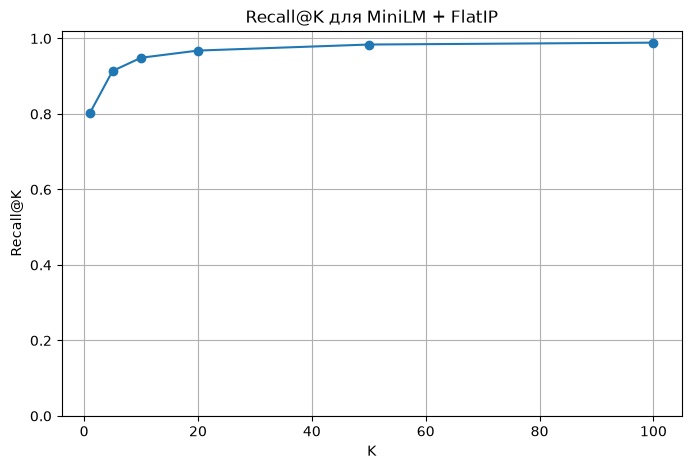

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    recall_df["k"],
    recall_df["recall"],
    marker="o"
)

plt.xlabel("K")
plt.ylabel("Recall@K")
plt.title("Recall@K для MiniLM + FlatIP")
plt.ylim(0, 1.02)
plt.grid()

plt.show()

In [25]:
RERANKER_NAME = "cross-encoder/ms-marco-MiniLM-L-6-v2"

reranker = CrossEncoder(
    RERANKER_NAME,
    device=str(device)
)

print("Reranker:", RERANKER_NAME)
print("Device:", device)

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 13123.60it/s]


Reranker: cross-encoder/ms-marco-MiniLM-L-6-v2
Device: cuda


In [26]:
TOP_CANDIDATES = 50

query_idx = 0
query = test_df.iloc[query_idx]["query"]
relevant_id = str(test_df.iloc[query_idx]["id"])

query_embedding = test_query_embeddings[query_idx:query_idx + 1]

scores, indices = index_flat.search(
    query_embedding,
    TOP_CANDIDATES
)

candidate_indices = indices[0]

candidates = corpus_df.iloc[candidate_indices].copy()

pairs = [
    [query, text]
    for text in candidates["text"].tolist()
]

reranker_scores = reranker.predict(
    pairs,
    batch_size=32,
    show_progress_bar=False
)

candidates["reranker_score"] = reranker_scores

reranked = candidates.sort_values(
    "reranker_score",
    ascending=False
).reset_index(drop=True)

display(
    reranked[
        ["id", "title", "reranker_score"]
    ].head(10)
)

print("Relevant ID:", relevant_id)

positions = reranked.index[
    reranked["id"].astype(str) == relevant_id
].tolist()

print(
    "Relevant document rank after reranking:",
    positions[0] + 1 if positions else "not in top-50"
)

,id,title,reranker_score
0,2412.16732,"Crystal structure of Nd10.67Pt4O24, a new neod...",4.257130
1,1006.4962,"Methane, ammonia, and their irradiation produc...",-3.992229
2,2507.17040,A Novel Discovery of Negative Thermal Expansio...,-5.497766
3,0803.1805,Modeling the Lukewarm Corino Phase - is L1527 ...,-5.772413
4,2012.05575,Investigating three Sirius-like systems with S...,-6.281069
5,0903.1975,Evidence for a change in the nuclear mass surf...,-7.061157
6,astro-ph/0605558,Probable detection of H2D+ in the starless cor...,-7.763753
7,1807.06542,Filamentary Structures and Star Formation Acti...,-7.973698
8,1312.1490,High Energy Density Mixed Polymeric Phase From...,-8.066725
9,cond-mat/0105102,Effects of mechanical strain on thermal denatu...,-8.165725


Relevant ID: 2412.16732
Relevant document rank after reranking: 1


## 16. Оценка Cross-encoder reranking

Проверим качество двухступенчатой retrieval-системы на всей тестовой выборке.

Для каждого запроса:

1. MiniLM + FlatIP извлекает top-50 кандидатов.
2. Cross-encoder оценивает пары query-document.
3. Кандидаты сортируются по score cross-encoder.
4. По итоговому ранжированию рассчитываются MRR@5 и Recall@5.

In [ ]:
def evaluate_reranker(
    index,
    query_embeddings,
    test_df,
    corpus_df,
    reranker,
    candidate_k=50,
    final_k=5,
    batch_size=32
):
    reciprocal_ranks = []
    recall_hits = 0

    corpus_ids = corpus_df["id"].astype(str).to_numpy()
    corpus_texts = corpus_df["text"].to_numpy()

    _, candidate_indices = index.search(
        query_embeddings,
        candidate_k
    )

    for i, (_, row) in enumerate(
        tqdm(
            test_df.iterrows(),
            total=len(test_df),
            desc="Reranking"
        )
    ):
        query = row["query"]
        relevant_id = str(row["id"])

        indices = candidate_indices[i]

        candidate_ids = corpus_ids[indices]
        candidate_texts = corpus_texts[indices]

        pairs = [
            [query, text]
            for text in candidate_texts
        ]

        scores = reranker.predict(
            pairs,
            batch_size=batch_size,
            show_progress_bar=False
        )

        order = np.argsort(-scores)

        reranked_ids = candidate_ids[order]

        top_ids = reranked_ids[:final_k]

        positions = np.where(
            reranked_ids == relevant_id
        )[0]

        if len(positions) > 0:
            rank = positions[0] + 1

            if rank <= final_k:
                reciprocal_ranks.append(1.0 / rank)
                recall_hits += 1
            else:
                reciprocal_ranks.append(0.0)
        else:
            reciprocal_ranks.append(0.0)

    return {
        "mrr@5": np.mean(reciprocal_ranks),
        "recall@5": recall_hits / len(test_df)
    }

In [28]:
start = time.perf_counter()

reranker_result = evaluate_reranker(
    index=index_flat,
    query_embeddings=test_query_embeddings,
    test_df=test_df,
    corpus_df=corpus_df,
    reranker=reranker,
    candidate_k=50,
    final_k=5,
    batch_size=32
)

elapsed = time.perf_counter() - start

print("MiniLM + FlatIP + CrossEncoder")
print(f"MRR@5:    {reranker_result['mrr@5']:.6f}")
print(f"Recall@5: {reranker_result['recall@5']:.6f}")
print(f"Time:     {elapsed:.2f} sec")

Reranking: 100%|██████████| 1000/1000 [00:44<00:00, 22.28it/s]

MiniLM + FlatIP + CrossEncoder
MRR@5:    0.936683
Recall@5: 0.973000
Time:     45.20 sec


## 17. Профилирование компонентов системы

Измеряем обработку всех тестовых запросов, включая кодирование MiniLM,
поиск FAISS, подготовку кандидатов, CrossEncoder, сортировку и метрики.
CUDA синхронизируется для корректного измерения вычислений GPU.
Кодирование и CrossEncoder включают токенизацию и перенос данных.

Этот запуск повторяет кодирование запросов и reranking всей выборки.
Среднее время на запрос в батче не является задержкой одиночного запроса.
Загрузка моделей и построение базы выполнены заранее и не входят в профиль.
Доли компонентов рассчитаны относительно общего времени; остаток — накладные расходы.


In [ ]:
def profile_retrieval(index, test_df, corpus_df, reranker, encode_fn,
                      candidate_k=50, final_k=5, batch_size=32):
    if len(test_df) == 0:
        raise ValueError("Тестовая выборка пуста")
    if not 1 <= final_k <= candidate_k <= index.ntotal:
        raise ValueError("Требуется 1 <= final_k <= candidate_k <= index.ntotal")
    if index.ntotal != len(corpus_df):
        raise ValueError("Размеры индекса и корпуса не совпадают")
    if batch_size < 1:
        raise ValueError("batch_size должен быть положительным")

    def synchronize():
        if torch.cuda.is_available():
            torch.cuda.synchronize(device)

    timings = {name: 0.0 for name in [
        "Подготовка данных", "Кодирование запросов", "Поиск FAISS",
        "Подготовка кандидатов", "CrossEncoder", "Сортировка и выдача",
        "Расчёт метрик",
    ]}

    synchronize()
    total_start = time.perf_counter()
    start = time.perf_counter()
    queries = test_df["query"].tolist()
    corpus_ids = corpus_df["id"].astype(str).to_numpy()
    texts = corpus_df["text"].to_numpy()
    timings["Подготовка данных"] = time.perf_counter() - start

    start = time.perf_counter()
    embeddings = encode_fn(queries)
    synchronize()
    timings["Кодирование запросов"] = time.perf_counter() - start

    start = time.perf_counter()
    _, candidates = index.search(embeddings, candidate_k)
    timings["Поиск FAISS"] = time.perf_counter() - start

    final_indices = np.empty((len(queries), final_k), dtype=np.int64)
    for i, query in enumerate(queries):
        start = time.perf_counter()
        indices = candidates[i]
        pairs = [[query, text] for text in texts[indices]]
        timings["Подготовка кандидатов"] += time.perf_counter() - start

        start = time.perf_counter()
        scores = reranker.predict(pairs, batch_size=batch_size,
                                  show_progress_bar=False)
        synchronize()
        timings["CrossEncoder"] += time.perf_counter() - start

        start = time.perf_counter()
        order = np.argsort(-np.asarray(scores))[:final_k]
        final_indices[i] = indices[order]
        timings["Сортировка и выдача"] += time.perf_counter() - start

    start = time.perf_counter()
    raw_metrics = metrics_from_indices(final_indices, test_df, corpus_ids, k=final_k)

    metrics = {f"mrr@{final_k}": raw_metrics["mrr@5"],
               f"recall@{final_k}": raw_metrics["recall@5"]}
    
    timings["Расчёт метрик"] = time.perf_counter() - start

    
    profile = pd.DataFrame({"component": list(timings),
                            "time_sec": list(timings.values())})
    
    profile["ms_per_query"] = profile["time_sec"] / len(queries) * 1000

    total_time = time.perf_counter() - total_start
    profile["share_percent"] = profile["time_sec"] / total_time * 100
    return {"metrics": metrics, "profile": profile,
            "total_time_sec": total_time,
            "overhead_sec": max(0.0, total_time - sum(timings.values())),
            "final_indices": final_indices}


MiniLM + FlatIP + CrossEncoder: временной профиль
MRR@5: 0.936683
Recall@5: 0.973000
Общее время: 44.38 sec
Накладные расходы: 0.0021 sec


,component,time_sec,ms_per_query,share_percent
0,Подготовка данных,0.0486,0.0486,0.1094
1,Кодирование запросов,0.2017,0.2017,0.4544
2,Поиск FAISS,0.2860,0.2860,0.6443
3,Подготовка кандидатов,0.0170,0.0170,0.0382
4,CrossEncoder,43.7611,43.7611,98.5995
5,Сортировка и выдача,0.0264,0.0264,0.0594
6,Расчёт метрик,0.0399,0.0399,0.0899


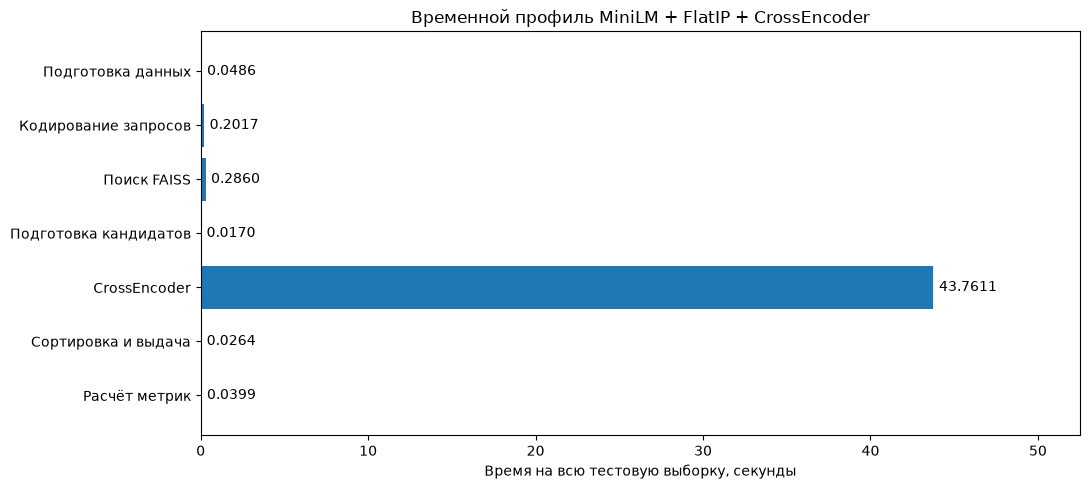

Самый медленный компонент: CrossEncoder (98.6% общего времени)


In [ ]:
profile_result = profile_retrieval(
    index=index_flat, test_df=test_df, corpus_df=corpus_df,
    reranker=reranker, encode_fn=encode_texts,
    candidate_k=50, final_k=5, batch_size=32,
)

print("MiniLM + FlatIP + CrossEncoder: временной профиль")
print(f"MRR@5: {profile_result['metrics']['mrr@5']:.6f}")
print(f"Recall@5: {profile_result['metrics']['recall@5']:.6f}")
print(f"Общее время: {profile_result['total_time_sec']:.2f} sec")
print(f"Накладные расходы: {profile_result['overhead_sec']:.4f} sec")

profile_df = profile_result["profile"]
display(profile_df.round(4))

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(profile_df["component"], profile_df["time_sec"])
ax.bar_label(bars, labels=[f"{v:.4f}" for v in profile_df["time_sec"]], padding=4)
ax.invert_yaxis()
ax.set_xlabel("Время на всю тестовую выборку, секунды")
ax.set_title("Временной профиль MiniLM + FlatIP + CrossEncoder")
ax.set_xlim(0, max(profile_df["time_sec"].max() * 1.2, 0.001))
plt.tight_layout()
plt.show()

slowest = profile_df.loc[profile_df["time_sec"].idxmax()]

print(f"Самый медленный компонент: {slowest['component']} "
      f"({slowest['share_percent']:.1f}% общего времени)")


# Выводы


Узкие места и ускорение:
- CrossEncoder: оценивает 50 000 пар для 1000 запросов. Ускорение: уменьшить top-50 до top-20, подобрать размер батча, использовать FP16. После изменений проверить MRR@5.
- Кодирование корпуса: занимает около 115 секунд при подготовке базы. Сохранять эмбеддинги и индекс, пересчитывать только изменённые статьи.
- Поиск FAISS: при росте корпуса использовать HNSW или IVF, контролируя качество выдачи.
Главный приоритет — ускорить CrossEncoder, сохранив MRR@5 > 0.91.
--------------------------

Итоговая система имеет архитектуру:

**Query → MiniLM → FAISS → top-50 → CrossEncoder → top-5**

Добавление CrossEncoder позволило увеличить **MRR@5 с 0.8472 до 0.9367**, что превышает целевое значение 0.91. Recall@5 составил 0.973.

Основное узкое место системы — **CrossEncoder**. Обработка 1000 запросов с 50 кандидатами требует оценки 50 000 пар `query-document` и занимает около 46 секунд. Поиск непосредственно в FAISS выполняется значительно быстрее.

Возможные способы ускорения системы:

- уменьшение числа кандидатов для reranking;
- batch-обработка и использование GPU/FP16;
- применение более лёгкого или квантизованного reranker;
- использование HNSW или IVF при значительном увеличении корпуса;
- предварительное вычисление embeddings документов и сохранение готового FAISS-индекса.

Таким образом, основным направлением оптимизации является ускорение этапа reranking при сохранении достигнутого качества поиска.